### Task VIII: Vision transformer/Quantum Vision Transformer

Implement a classical Vision transformer and apply it to MNIST. Show its performance on the test data. Comment on potential ideas to extend this classical vision transformer architecture to a quantum vision transformer and sketch out the architecture in detail.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

A transformer is a neural network architecture originally designed for sequence modeling, built around the idea of self‑attention. Instead of processing inputs sequentially like RNNs, transformers look at all tokens (or patches, in vision tasks) at once and compute relationships between them. The key components are:

- **Embedding layer:** maps raw inputs into a continuous vector space.

- **Positional encoding:** adds information about order or spatial location.

- **Multi‑head self‑attention:** lets the model learn how each element relates to others.

- **Feedforward layers:** apply nonlinear transformations to the attended features.

- **Stacked encoder blocks:** repeat attention + feedforward layers for depth.

- **Pooling/classification head:** condenses the sequence into a single prediction.

In [2]:
# MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


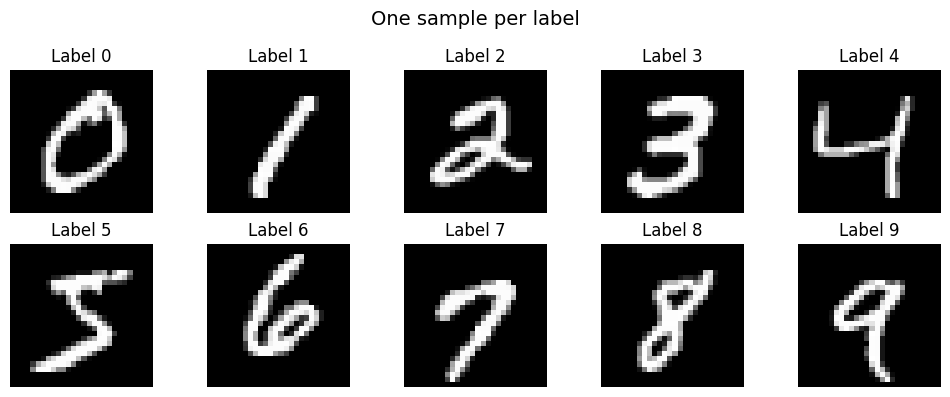

In [3]:
# Helper to unnormalize and plot
def imshow(img, ax):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy().squeeze()
    ax.imshow(npimg, cmap="gray")
    ax.axis("off")

# Collect one sample per label
labels_to_show = list(range(10))
images = []
for label in labels_to_show:
    idx = next(i for i, (img, lab) in enumerate(train_dataset) if lab == label)
    images.append(train_dataset[idx][0])

# Plot all labels in 2 rows × 5 columns
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("One sample per label", fontsize=14)

for idx, ax in enumerate(axes.flat):
    imshow(images[idx], ax)
    ax.set_title(f"Label {labels_to_show[idx]}")

plt.tight_layout()
plt.show()



In [4]:
class ViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, emb_dim=64, num_heads=4, num_layers=4, num_classes=10):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.emb_dim = emb_dim

        # Linear projection of flattened patches
        self.patch_embed = nn.Linear(patch_size*patch_size, emb_dim)

        # Positional embeddings
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, emb_dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads, dim_feedforward=128)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head
        self.fc = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        # x: (batch, 1, 28, 28)
        B = x.size(0)
        x = x.squeeze(1)  # (B, 28, 28)

        # Split into patches
        patches = x.unfold(1, self.patch_size, self.patch_size).unfold(2, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(B, -1, self.patch_size*self.patch_size)  # (B, num_patches, patch_dim)

        # Embed patches
        x = self.patch_embed(patches) + self.pos_embed  # (B, num_patches, emb_dim)

        # Transformer expects (seq_len, batch, emb_dim)
        x = x.permute(1, 0, 2)

        # Encode
        x = self.transformer(x)

        # Take mean pooling over patches
        x = x.mean(dim=0)

        return self.fc(x)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViT().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

/tmp/ipykernel_10887/2050282196.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [6]:
# Training loop
losses = []
for epoch in range(15):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
    losses.append(total_loss)

Epoch 1, Loss: 0.4126
Epoch 2, Loss: 0.1578
Epoch 3, Loss: 0.1242
Epoch 4, Loss: 0.1061
Epoch 5, Loss: 0.0941
Epoch 6, Loss: 0.0860
Epoch 7, Loss: 0.0799
Epoch 8, Loss: 0.0771
Epoch 9, Loss: 0.0697
Epoch 10, Loss: 0.0656
Epoch 11, Loss: 0.0649
Epoch 12, Loss: 0.0608
Epoch 13, Loss: 0.0586
Epoch 14, Loss: 0.0568
Epoch 15, Loss: 0.0535


Text(0.5, 1.0, 'Training Loss')

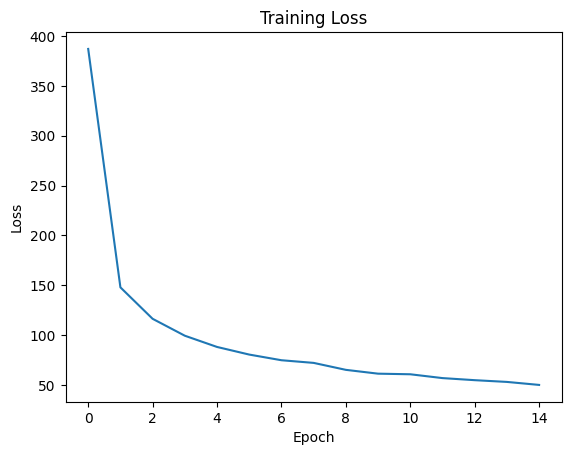

In [7]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

In [8]:
# Testing
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.45%
